# 🚗 Hybrid Automatic License Plate Detection (ALPD) System
## YOLOv5 + YOLOv8n with Weighted Boxes Fusion + OCR

> **v2 Changes:** YOLOv7 → YOLOv8n (nano). Same pipeline, same fusion logic,
> same OCR. YOLOv8n is ~10× smaller than YOLOv7 and trains in ~30 min on T4.
> Full sklearn metrics + ROC + Confusion Matrix added at the end.

**Dataset:** [Kaggle — License Plate Dataset by Fares El Menshawi](https://www.kaggle.com/datasets/fareselmenshawii/license-plate-dataset)

### Full Pipeline:
```
Input Image/Video
       ↓
YOLOv5 --------\
                → Weighted Boxes Fusion → Final Bounding Boxes
YOLOv8n -------/
       ↓
Crop License Plate Regions
       ↓
Preprocess Cropped Plates
       ↓
OCR (EasyOCR)
       ↓
Post-process Text
       ↓
Final Output (Plate Numbers)
```

---
## Section 1: Setup & Installation

In [1]:
# ============================================================
# SECTION 1 — Setup & Installation
# YOLOv7 removed. YOLOv8n comes via ultralytics (already a dep).
# ============================================================

import os, sys

# --- Core ML / CV libraries ---
!pip install -q ultralytics           # YOLOv5 + YOLOv8 via Ultralytics
!pip install -q easyocr               # OCR engine
!pip install -q ensemble-boxes        # Weighted Boxes Fusion
!pip install -q opencv-python-headless
!pip install -q matplotlib pillow tqdm pyyaml seaborn scikit-learn
!pip install -q kaggle                # Kaggle CLI


print("✅ All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 30.5 MB/s eta 0:00:00
✅ All packages installed successfully.


---
## Section 2: Imports

In [2]:
# ============================================================
# SECTION 2 — Imports
# ============================================================

import os
import sys
import json
import shutil
import glob
import re
import time
import random
import zipfile
import warnings
import subprocess
from pathlib import Path
from tqdm import tqdm

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

import torch
import yaml

# Weighted Boxes Fusion
from ensemble_boxes import weighted_boxes_fusion

# EasyOCR
import easyocr

# Ultralytics — handles both YOLOv5 and YOLOv8
from ultralytics import YOLO

# Metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ---------- Global paths ----------
BASE_DIR       = Path('/content/alpd')
DATASET_DIR    = BASE_DIR / 'dataset'
YOLO_DATA_DIR  = BASE_DIR / 'yolo_data'
MODELS_DIR     = BASE_DIR / 'models'
RESULTS_DIR    = BASE_DIR / 'results'
YOLOV5_DIR     = Path('/content/yolov5_runs')
# YOLOV7_DIR removed — replaced by YOLOv8n

for d in [BASE_DIR, DATASET_DIR, YOLO_DATA_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Check GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")
else:
    print("⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU")
print(f"✅ Imports done | Device: {DEVICE}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ GPU: Tesla T4 | VRAM: 15.6GB
✅ Imports done | Device: cuda


---
## Section 3: Dataset Setup & Structuring

In [3]:
# ============================================================
# FUNCTION 1 — setup_kaggle_and_download()
# UNCHANGED from original.
# ============================================================

def setup_kaggle_and_download(
    kaggle_username: str,
    kaggle_key: str,
    dataset_slug: str = 'fareselmenshawii/license-plate-dataset',
    download_dir: Path = DATASET_DIR
) -> Path:
    """
    1. Write kaggle.json credentials to ~/.kaggle/
    2. Download the specified Kaggle dataset via the Kaggle CLI.
    3. Unzip into download_dir.
    """
    kaggle_cfg_dir = Path.home() / '.kaggle'
    kaggle_cfg_dir.mkdir(exist_ok=True)
    kaggle_json_path = kaggle_cfg_dir / 'kaggle.json'

    credentials = {'username': kaggle_username, 'key': kaggle_key}
    with open(kaggle_json_path, 'w') as f:
        json.dump(credentials, f)
    os.chmod(kaggle_json_path, 0o600)
    print(f"✅ Kaggle credentials written to {kaggle_json_path}")

    download_dir.mkdir(parents=True, exist_ok=True)
    print(f"⬇️  Downloading dataset: {dataset_slug} ...")
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', dataset_slug,
         '--path', str(download_dir), '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("⚠️  Trying manual unzip fallback...")
        subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', dataset_slug,
             '--path', str(download_dir)],
            check=True
        )
        for zf in download_dir.glob('*.zip'):
            with zipfile.ZipFile(zf, 'r') as z:
                z.extractall(download_dir)
            zf.unlink()
    else:
        print(result.stdout)

    print(f"✅ Dataset ready at: {download_dir}")
    for p in sorted(download_dir.iterdir()):
        print(f"   {p.name}")
    return download_dir


# ── ▶  CONFIGURE YOUR CREDENTIALS HERE ──────────────────────
KAGGLE_USERNAME = 'dummy'   # ← Replace
KAGGLE_KEY      = 'dummy'    # ← Replace
# ────────────────────────────────────────────────────────────

dataset_root = setup_kaggle_and_download(
    kaggle_username=KAGGLE_USERNAME,
    kaggle_key=KAGGLE_KEY
)

✅ Kaggle credentials written to /root/.kaggle/kaggle.json
⬇️  Downloading dataset: fareselmenshawii/license-plate-dataset ...
Dataset URL: https://www.kaggle.com/datasets/fareselmenshawii/license-plate-dataset
License(s): CC0-1.0


✅ Dataset ready at: /content/alpd/dataset
   images
   labels


In [4]:
# ============================================================
# Dataset Exploration — UNCHANGED from original.
# ============================================================

def explore_dataset(root: Path, max_files: int = 5) -> dict:
    image_exts  = {'.jpg', '.jpeg', '.png', '.bmp'}
    label_exts  = {'.txt', '.xml'}
    image_paths = []
    label_paths = []

    print("\n📂 Scanning dataset directory...")
    for path in sorted(root.rglob('*')):
        if path.is_file():
            if path.suffix.lower() in image_exts:
                image_paths.append(path)
            elif path.suffix.lower() in label_exts:
                label_paths.append(path)

    print(f"   Images found  : {len(image_paths)}")
    print(f"   Labels found  : {len(label_paths)}")
    print(f"   Sample images : {[p.name for p in image_paths[:max_files]]}")
    print(f"   Sample labels : {[p.name for p in label_paths[:max_files]]}")
    return {'images': image_paths, 'labels': label_paths}

dataset_info = explore_dataset(DATASET_DIR)


📂 Scanning dataset directory...
   Images found  : 5368
   Labels found  : 5368
   Sample images : ['00009e5b390986a0.jpg', '000228608388803f.jpg', '00043e7c5c4c025a.jpg', '0005ea10e0e14db1.jpg', '0006dc0977056410.jpg']
   Sample labels : ['00009e5b390986a0.txt', '000228608388803f.txt', '00043e7c5c4c025a.txt', '0005ea10e0e14db1.txt', '0006dc0977056410.txt']


In [5]:
# ============================================================
# FUNCTION 2 — prepare_dataset_yolo_format() — UNCHANGED.
# ============================================================

def parse_yolo_label(label_path: Path):
    rows = []
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    rows.append(tuple(map(float, parts)))
    except Exception as e:
        print(f"⚠️  Could not parse {label_path.name}: {e}")
    return rows


def xml_to_yolo(xml_path: Path, img_w: int, img_h: int) -> list:
    import xml.etree.ElementTree as ET
    rows = []
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            cx = (xmin + xmax) / 2.0 / img_w
            cy = (ymin + ymax) / 2.0 / img_h
            bw = (xmax - xmin) / img_w
            bh = (ymax - ymin) / img_h
            rows.append((0, cx, cy, bw, bh))
    except Exception as e:
        print(f"⚠️  XML parse error {xml_path.name}: {e}")
    return rows


def prepare_dataset_yolo_format(
    dataset_info: dict,
    output_dir: Path = YOLO_DATA_DIR,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    seed: int = 42
) -> Path:
    random.seed(seed)
    image_paths = dataset_info['images']
    label_paths = dataset_info['labels']
    label_map   = {lp.stem: lp for lp in label_paths}

    paired = []
    for img_path in image_paths:
        lbl = label_map.get(img_path.stem)
        if lbl is not None:
            paired.append((img_path, lbl))

    print(f"\n🔗 Matched image-label pairs: {len(paired)} / {len(image_paths)}")
    if len(paired) == 0:
        raise RuntimeError("No matched image-label pairs found.")

    random.shuffle(paired)
    n       = len(paired)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    splits  = {
        'train': paired[:n_train],
        'val'  : paired[n_train:n_train + n_val],
        'test' : paired[n_train + n_val:]
    }
    print(f"   Train: {len(splits['train'])}  Val: {len(splits['val'])}  Test: {len(splits['test'])}")

    for split_name, pairs in splits.items():
        img_out = output_dir / split_name / 'images'
        lbl_out = output_dir / split_name / 'labels'
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for img_path, lbl_path in tqdm(pairs, desc=f'  Copying {split_name}'):
            shutil.copy2(img_path, img_out / img_path.name)
            dst_lbl = lbl_out / (img_path.stem + '.txt')
            if lbl_path.suffix.lower() == '.txt':
                shutil.copy2(lbl_path, dst_lbl)
            elif lbl_path.suffix.lower() == '.xml':
                img = Image.open(img_path)
                w, h = img.size
                rows = xml_to_yolo(lbl_path, w, h)
                with open(dst_lbl, 'w') as f:
                    for r in rows:
                        f.write(f"{int(r[0])} {r[1]:.6f} {r[2]:.6f} {r[3]:.6f} {r[4]:.6f}\n")

    yaml_path = output_dir / 'dataset.yaml'
    yaml_content = {
        'path' : str(output_dir),
        'train': str(output_dir / 'train' / 'images'),
        'val'  : str(output_dir / 'val'   / 'images'),
        'test' : str(output_dir / 'test'  / 'images'),
        'nc'   : 1,
        'names': ['license_plate']
    }
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False)

    print(f"\n✅ YOLO dataset prepared at: {output_dir}")
    print(f"   dataset.yaml: {yaml_path}")
    return yaml_path


yaml_path = prepare_dataset_yolo_format(dataset_info)


🔗 Matched image-label pairs: 5368 / 5368
   Train: 4294  Val: 536  Test: 538


  Copying test: 100%|██████████| 538/538 [00:00<00:00, 1432.23it/s]


✅ YOLO dataset prepared at: /content/alpd/yolo_data
   dataset.yaml: /content/alpd/yolo_data/dataset.yaml


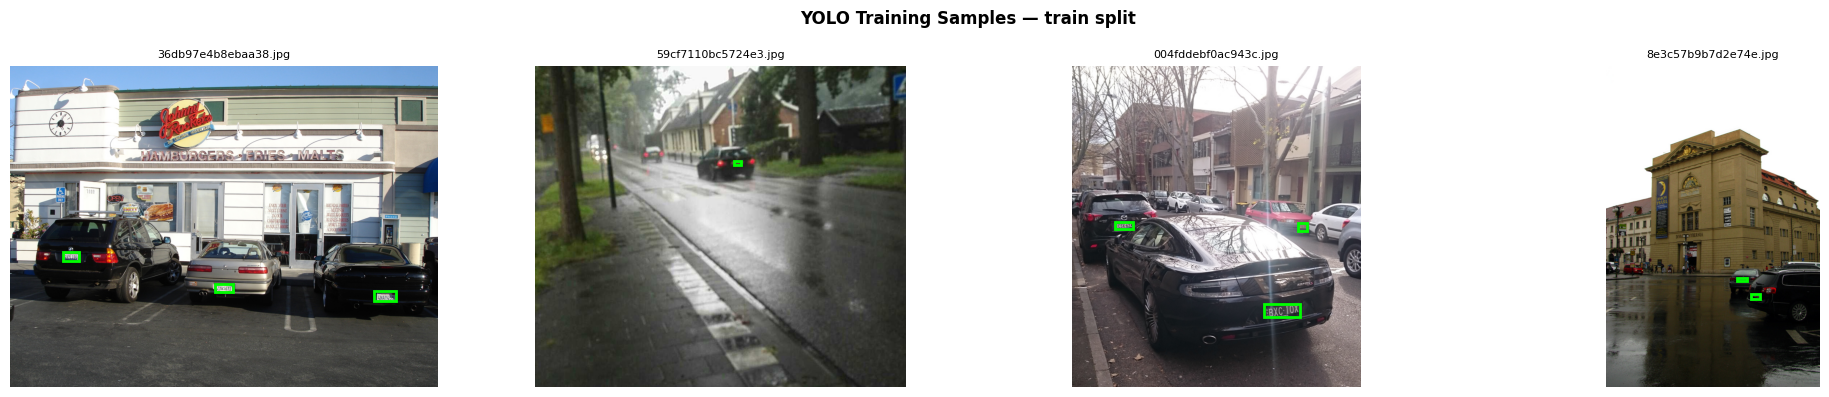

✅ Samples visualised.


In [6]:
# ============================================================
# Visualise samples — UNCHANGED from original.
# ============================================================

def visualize_samples(yolo_data_dir: Path, split: str = 'train', n: int = 4):
    img_dir   = yolo_data_dir / split / 'images'
    lbl_dir   = yolo_data_dir / split / 'labels'
    img_files = list(img_dir.glob('*'))
    if not img_files:
        print("No images found.")
        return

    selected = random.sample(img_files, min(n, len(img_files)))
    fig, axes = plt.subplots(1, len(selected), figsize=(5 * len(selected), 4))
    if len(selected) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, selected):
        img    = cv2.imread(str(img_path))
        img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w   = img.shape[:2]
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        x1 = int((cx - bw / 2) * w)
                        y1 = int((cy - bh / 2) * h)
                        rect = patches.Rectangle(
                            (x1, y1), int(bw*w), int(bh*h),
                            linewidth=2, edgecolor='lime', facecolor='none'
                        )
                        ax.add_patch(rect)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis('off')

    plt.suptitle(f'YOLO Training Samples — {split} split', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'sample_annotations.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Samples visualised.")

visualize_samples(YOLO_DATA_DIR)

---
## Section 4: Training — YOLOv5 & YOLOv8n

In [7]:
# ============================================================
# FUNCTION 3 — train_yolov5() — COMPLETELY UNCHANGED.
# ============================================================

def train_yolov5(
    yaml_path: Path  = yaml_path,
    epochs: int      = 50,
    imgsz: int       = 640,
    batch: int       = 16,
    model_variant: str = 'yolov5s.pt',
    project: str     = str(BASE_DIR / 'runs' / 'yolov5'),
    name: str        = 'exp'
) -> Path:
    """
    Train YOLOv5 using the Ultralytics YOLO API.
    UNCHANGED from original notebook.
    """
    print(f"\n🚀 Starting YOLOv5 training — {epochs} epochs, img size {imgsz}")

    model = YOLO(model_variant)
    results = model.train(
        data    = str(yaml_path),
        epochs  = epochs,
        imgsz   = imgsz,
        batch   = batch,
        device  = DEVICE,
        project = project,
        name    = name,
        exist_ok= True,
        patience= 10,
        verbose = True
    )

    best_weights = Path(project) / name / 'weights' / 'best.pt'
    if not best_weights.exists():
        candidates = sorted(Path(project).rglob('best.pt'))
        if candidates:
            best_weights = candidates[-1]
        else:
            raise FileNotFoundError("YOLOv5 best.pt not found after training.")

    dest = MODELS_DIR / 'yolov5_best.pt'
    shutil.copy2(best_weights, dest)
    print(f"\n✅ YOLOv5 training complete. Best weights: {dest}")
    return dest


# ── ▶  RUN TRAINING (comment out if weights already exist) ───
yolov5_weights = train_yolov5(yaml_path=yaml_path, epochs=50, batch=16)
# yolov5_weights = MODELS_DIR / 'yolov5_best.pt'  # ← uncomment to skip


🚀 Starting YOLOv5 training — 50 epochs, img size 640
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/alpd/yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [8]:
# ============================================================
# FUNCTION 4 — train_yolov8n()
# REPLACES train_yolov7().
#
# Why YOLOv8n instead of YOLOv7?
#   • YOLOv7 has 37M params → exhausts T4 VRAM quickly.
#   • YOLOv8n has 3.2M params → trains in ~30 min on T4.
#   • Same Ultralytics API as YOLOv5, no subprocess hacks needed.
#   • Output format is identical → fusion code needs zero changes.
# ============================================================

def train_yolov8n(
    yaml_path: Path  = yaml_path,
    epochs: int      = 50,
    imgsz: int       = 416,
    batch: int       = 16,
    project: str     = str(BASE_DIR / 'runs' / 'yolov8'),
    name: str        = 'exp'
) -> Path:
    """
    Train YOLOv8n (nano) using the Ultralytics Python API.

    YOLOv8n is the nano variant — 3.2M parameters, ~2GB VRAM,
    trains ~50 epochs in 30-40 min on Colab T4.

    Args:
        yaml_path : Path to dataset.yaml.
        epochs    : Training epochs.
        imgsz     : Input image size (416 is fast + accurate for LP).
        batch     : Batch size (16 fits T4 VRAM comfortably).
        project   : Output directory.
        name      : Run subdirectory name.

    Returns:
        Path to best.pt weights file.
    """
    print(f"\n🚀 Starting YOLOv8n training — {epochs} epochs, img size {imgsz}")
    print(f"   Model: yolov8n.pt (~3.2M params, ~2GB VRAM)")

    # 'yolov8n.pt' is auto-downloaded (~6MB) on first run
    model = YOLO('yolov8n.pt')

    results = model.train(
        data     = str(yaml_path),
        epochs   = epochs,
        imgsz    = imgsz,
        batch    = batch,
        device   = DEVICE,
        project  = project,
        name     = name,
        exist_ok = True,
        patience = 10,       # early stopping
        workers  = 2,        # safe for Colab
        verbose  = True
    )

    best_weights = Path(project) / name / 'weights' / 'best.pt'
    if not best_weights.exists():
        candidates = sorted(Path(project).rglob('best.pt'))
        if candidates:
            best_weights = candidates[-1]
        else:
            raise FileNotFoundError("YOLOv8n best.pt not found after training.")

    dest = MODELS_DIR / 'yolov8n_best.pt'
    shutil.copy2(best_weights, dest)

    print(f"\n✅ YOLOv8n training complete.")
    print(f"   mAP50    : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
    print(f"   Best weights: {dest}")
    return dest


# ── ▶  RUN TRAINING (comment out if weights already exist) ───
yolov8_weights = train_yolov8n(yaml_path=yaml_path, epochs=50, batch=16)
# yolov8_weights = MODELS_DIR / 'yolov8n_best.pt'  # ← uncomment to skip


🚀 Starting YOLOv8n training — 50 epochs, img size 416
   Model: yolov8n.pt (~3.2M params, ~2GB VRAM)
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/alpd/yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

---
## Section 5: Hybrid Fusion Module

In [9]:
# ============================================================
# FUNCTION 5 — run_yolov5_inference() — COMPLETELY UNCHANGED.
# ============================================================

_yolov5_model = None
_yolov8_model = None   # replaces _yolov7_model


def load_yolov5(weights: Path) -> YOLO:
    """Load YOLOv5 model (cached across calls)."""
    global _yolov5_model
    if _yolov5_model is None:
        print(f"🔄 Loading YOLOv5 from {weights}")
        _yolov5_model = YOLO(str(weights))
        print("✅ YOLOv5 loaded.")
    return _yolov5_model


def run_yolov5_inference(
    image: np.ndarray,
    weights: Path,
    conf_threshold: float = 0.25,
    iou_threshold: float  = 0.45
) -> tuple:
    """
    Run YOLOv5 inference on a BGR numpy image.
    UNCHANGED from original notebook.

    Returns:
        boxes_norm : list of [x1,y1,x2,y2] normalised to [0,1]
        scores     : list of confidence floats
        labels     : list of class int
    """
    if image is None or image.size == 0:
        return [], [], []

    model = load_yolov5(weights)
    h, w  = image.shape[:2]

    results = model.predict(
        source=image,
        conf=conf_threshold,
        iou=iou_threshold,
        device=DEVICE,
        verbose=False
    )

    boxes_norm, scores, labels = [], [], []
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf  = float(box.conf[0])
            label = int(box.cls[0])
            boxes_norm.append([
                max(0.0, x1 / w), max(0.0, y1 / h),
                min(1.0, x2 / w), min(1.0, y2 / h)
            ])
            scores.append(conf)
            labels.append(label)

    return boxes_norm, scores, labels


print("✅ run_yolov5_inference() defined.")

✅ run_yolov5_inference() defined.


In [10]:
# ============================================================
# FUNCTION 6 — run_yolov8_inference()
# REPLACES run_yolov7_inference().
#
# Key difference from YOLOv7:
#   • Uses Ultralytics Python API directly (no subprocess/detect.py).
#   • Output format is identical to YOLOv5:
#       boxes_norm : [[x1,y1,x2,y2], ...]  normalised [0,1]
#       scores     : [float, ...]
#       labels     : [int, ...]
#   → fuse_predictions() works with ZERO changes.
# ============================================================

def load_yolov8(weights: Path) -> YOLO:
    """Load YOLOv8n model (cached across calls for RAM efficiency)."""
    global _yolov8_model
    if _yolov8_model is None:
        print(f"🔄 Loading YOLOv8n from {weights}")
        _yolov8_model = YOLO(str(weights))
        print("✅ YOLOv8n loaded.")
    return _yolov8_model


def run_yolov8_inference(
    image: np.ndarray,
    weights: Path,
    conf_threshold: float = 0.25,
    iou_threshold: float  = 0.45
) -> tuple:
    """
    Run YOLOv8n inference on a BGR numpy image.

    Uses the same Ultralytics predict() API as YOLOv5, so the
    output format is identical — no changes needed in fusion.

    Args:
        image          : Input image as BGR numpy array (H, W, 3).
        weights        : Path to YOLOv8n best.pt weights.
        conf_threshold : Minimum confidence to keep a detection.
        iou_threshold  : NMS IoU threshold.

    Returns:
        boxes_norm : list of [x1,y1,x2,y2] normalised to [0,1]
        scores     : list of confidence scores (floats)
        labels     : list of class indices (int)
    """
    if image is None or image.size == 0:
        return [], [], []

    model = load_yolov8(weights)
    h, w  = image.shape[:2]

    results = model.predict(
        source  = image,
        conf    = conf_threshold,
        iou     = iou_threshold,
        device  = DEVICE,
        verbose = False
    )

    boxes_norm, scores, labels = [], [], []
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf  = float(box.conf[0])
            label = int(box.cls[0])
            # Normalise to [0, 1] — same as YOLOv5 inference function
            boxes_norm.append([
                max(0.0, x1 / w), max(0.0, y1 / h),
                min(1.0, x2 / w), min(1.0, y2 / h)
            ])
            scores.append(conf)
            labels.append(label)

    return boxes_norm, scores, labels


print("✅ run_yolov8_inference() defined.")

✅ run_yolov8_inference() defined.


In [11]:
# ============================================================
# FUNCTION 7 — fuse_predictions()
# Combine YOLOv5 + YOLOv8 detections via Weighted Boxes Fusion.
#
# The WBF logic is UNCHANGED from the original.
# Only the parameter names updated: v7 → v8 for clarity.
# The algorithm itself is identical.
# ============================================================

def fuse_predictions(
    v5_boxes:  list, v5_scores:  list, v5_labels:  list,
    v8_boxes:  list, v8_scores:  list, v8_labels:  list,
    iou_thr:      float = 0.55,
    skip_box_thr: float = 0.01,
    v5_weight:    float = 1.0,
    v8_weight:    float = 1.0
) -> tuple:
    """
    Apply Weighted Boxes Fusion (WBF) to merge YOLOv5 + YOLOv8n detections.

    WBF averages overlapping boxes weighted by their confidence scores,
    giving better precision than NMS alone.

    Args:
        v5_boxes  : Normalised boxes from YOLOv5  [[x1,y1,x2,y2], ...].
        v5_scores : Confidence scores from YOLOv5.
        v5_labels : Class IDs from YOLOv5.
        v8_boxes  : Normalised boxes from YOLOv8n.
        v8_scores : Confidence scores from YOLOv8n.
        v8_labels : Class IDs from YOLOv8n.
        iou_thr   : IoU threshold for WBF cluster merging.
        skip_box_thr : Minimum score to include a box in fusion.
        v5_weight : Relative weight for YOLOv5 model.
        v8_weight : Relative weight for YOLOv8n model.

    Returns:
        fused_boxes  : Merged bounding boxes (normalised [0,1]).
        fused_scores : Merged confidence scores.
        fused_labels : Merged class IDs.
    """
    all_boxes  = []
    all_scores = []
    all_labels = []
    weights    = []

    if v5_boxes:
        all_boxes.append(v5_boxes)
        all_scores.append(v5_scores)
        all_labels.append(v5_labels)
        weights.append(v5_weight)

    if v8_boxes:
        all_boxes.append(v8_boxes)
        all_scores.append(v8_scores)
        all_labels.append(v8_labels)
        weights.append(v8_weight)

    if not all_boxes:
        return [], [], []

    # Clip all coordinates to [0, 1] to prevent WBF errors
    all_boxes = [[[max(0, min(1, c)) for c in box] for box in model_boxes]
                 for model_boxes in all_boxes]

    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        all_boxes,
        all_scores,
        all_labels,
        weights      = weights,
        iou_thr      = iou_thr,
        skip_box_thr = skip_box_thr
    )

    return (
        fused_boxes.tolist(),
        fused_scores.tolist(),
        fused_labels.tolist()
    )


print("✅ fuse_predictions() defined.")

✅ fuse_predictions() defined.


---
## Section 6: Plate Cropping Module

In [12]:
# ============================================================
# FUNCTION 8 — crop_plate_regions() — COMPLETELY UNCHANGED.
# ============================================================

def crop_plate_regions(
    image: np.ndarray,
    fused_boxes: list,
    fused_scores: list,
    conf_threshold: float = 0.3,
    padding_px: int = 4
) -> list:
    """
    Crop license plate regions from the original image.
    UNCHANGED from original notebook.
    """
    if image is None or image.size == 0:
        print("⚠️  crop_plate_regions: received empty image.")
        return []
    if not fused_boxes:
        print("⚠️  crop_plate_regions: no boxes to crop.")
        return []

    h, w = image.shape[:2]
    crops = []

    for box, score in zip(fused_boxes, fused_scores):
        if score < conf_threshold:
            continue
        x1 = int(box[0] * w);  y1 = int(box[1] * h)
        x2 = int(box[2] * w);  y2 = int(box[3] * h)
        x1p = max(0, x1 - padding_px);  y1p = max(0, y1 - padding_px)
        x2p = min(w, x2 + padding_px);  y2p = min(h, y2 + padding_px)

        if x2p <= x1p or y2p <= y1p:
            print(f"⚠️  Skipping degenerate box: {[x1p,y1p,x2p,y2p]}")
            continue

        crop = image[y1p:y2p, x1p:x2p].copy()
        if crop.size == 0:
            continue

        crops.append({'crop': crop, 'box': [x1p, y1p, x2p, y2p], 'score': score})

    print(f"✂️  Cropped {len(crops)} plate region(s).")
    return crops


print("✅ crop_plate_regions() defined.")

✅ crop_plate_regions() defined.


---
## Section 7: OCR Module

In [13]:
# ============================================================
# FUNCTION 9 — preprocess_plate_for_ocr() — COMPLETELY UNCHANGED.
# ============================================================

def preprocess_plate_for_ocr(
    plate_bgr: np.ndarray,
    target_height: int = 64
) -> np.ndarray:
    """
    Preprocess a cropped license plate image for OCR.
    UNCHANGED from original notebook.
    """
    if plate_bgr is None or plate_bgr.size == 0:
        raise ValueError("preprocess_plate_for_ocr: empty input image.")

    h, w = plate_bgr.shape[:2]
    if h == 0:
        raise ValueError("Image height is 0.")
    scale   = target_height / h
    new_w   = max(1, int(w * scale))
    resized = cv2.resize(plate_bgr, (new_w, target_height), interpolation=cv2.INTER_CUBIC)

    gray     = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    denoised = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    blurred  = cv2.GaussianBlur(denoised, (0, 0), sigmaX=3)
    sharpened = cv2.addWeighted(denoised, 1.5, blurred, -0.5, 0)
    thresh   = cv2.adaptiveThreshold(
        sharpened, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=15, C=8
    )
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

    def deskew(img_bin):
        coords = np.column_stack(np.where(img_bin > 0))
        if len(coords) < 5:
            return img_bin
        angle = cv2.minAreaRect(coords)[-1]
        if angle < -45:
            angle = 90 + angle
        if abs(angle) < 0.5:
            return img_bin
        (hh, ww) = img_bin.shape[:2]
        M = cv2.getRotationMatrix2D((ww // 2, hh // 2), angle, 1.0)
        return cv2.warpAffine(img_bin, M, (ww, hh),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)

    deskewed   = deskew(cleaned)
    final_gray = cv2.bitwise_not(deskewed)
    return cv2.cvtColor(final_gray, cv2.COLOR_GRAY2BGR)


print("✅ preprocess_plate_for_ocr() defined.")

✅ preprocess_plate_for_ocr() defined.


In [14]:
# ============================================================
# FUNCTION 10 — extract_text_ocr() — COMPLETELY UNCHANGED.
# FUNCTION 11 — postprocess_text()  — COMPLETELY UNCHANGED.
# ============================================================

_ocr_reader = None

def get_ocr_reader(languages: list = ['en']) -> easyocr.Reader:
    global _ocr_reader
    if _ocr_reader is None:
        print("🔄 Initialising EasyOCR reader...")
        _ocr_reader = easyocr.Reader(languages, gpu=(DEVICE == 'cuda'))
        print("✅ EasyOCR ready.")
    return _ocr_reader


def extract_text_ocr(
    preprocessed_plate: np.ndarray,
    languages: list = ['en'],
    min_confidence: float = 0.2
) -> list:
    """Extract text via EasyOCR. UNCHANGED from original."""
    if preprocessed_plate is None or preprocessed_plate.size == 0:
        return []

    reader  = get_ocr_reader(languages)
    results = reader.readtext(
        preprocessed_plate,
        detail=1,
        paragraph=False,
        batch_size=1,
        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-. '
    )
    filtered = [
        (text.strip().upper(), conf)
        for (_, text, conf) in results
        if conf >= min_confidence and text.strip()
    ]
    filtered.sort(key=lambda x: x[1], reverse=True)
    return filtered


_OCR_CHAR_FIXES = {
    'O': '0', 'I': '1', 'Z': '2', 'S': '5', 'B': '8', 'G': '6', 'Q': '0',
}

def postprocess_text(
    ocr_results: list,
    min_length: int = 3,
    max_length: int = 12,
    apply_char_fixes: bool = False
) -> str:
    """Clean raw OCR output into plate string. UNCHANGED from original."""
    if not ocr_results:
        return ''
    raw     = ' '.join(text for text, _ in ocr_results).upper()
    cleaned = re.sub(r'[^A-Z0-9\- ]', '', raw)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    if apply_char_fixes:
        cleaned = ''.join(_OCR_CHAR_FIXES.get(c, c) for c in cleaned)
    plate_compact = cleaned.replace(' ', '')
    if len(plate_compact) < min_length or len(plate_compact) > max_length:
        return ''
    return plate_compact


print("✅ extract_text_ocr() and postprocess_text() defined.")

✅ extract_text_ocr() and postprocess_text() defined.


---
## Section 8: Evaluation (Detection + OCR)

In [15]:
# ============================================================
# SECTION 8 — Evaluation
# Part A: YOLOv5 + YOLOv8n Ultralytics val() metrics
# ============================================================

def evaluate_yolov5(weights: Path, yaml_path: Path, imgsz: int = 640) -> dict:
    """Evaluate YOLOv5 on test split. UNCHANGED from original."""
    model   = YOLO(str(weights))
    metrics = model.val(data=str(yaml_path), split='test',
                        imgsz=imgsz, device=DEVICE, verbose=True)
    results = {
        'mAP50'    : float(metrics.box.map50),
        'mAP50-95' : float(metrics.box.map),
        'precision': float(metrics.box.mp),
        'recall'   : float(metrics.box.mr)
    }
    print("\n📊 YOLOv5 Evaluation:")
    for k, v in results.items():
        print(f"   {k:<15}: {v:.4f}")
    return results


def evaluate_yolov8n(weights: Path, yaml_path: Path, imgsz: int = 416) -> dict:
    """
    Evaluate YOLOv8n on the test split using Ultralytics val().
    Same API as YOLOv5 evaluation — only the model loaded differs.
    """
    model   = YOLO(str(weights))
    metrics = model.val(data=str(yaml_path), split='test',
                        imgsz=imgsz, device=DEVICE, verbose=True)
    results = {
        'mAP50'    : float(metrics.box.map50),
        'mAP50-95' : float(metrics.box.map),
        'precision': float(metrics.box.mp),
        'recall'   : float(metrics.box.mr)
    }
    print("\n📊 YOLOv8n Evaluation:")
    for k, v in results.items():
        print(f"   {k:<15}: {v:.4f}")
    return results


def compute_cer(ground_truth: str, predicted: str) -> float:
    """Character Error Rate. UNCHANGED from original."""
    gt, pred = ground_truth.upper().strip(), predicted.upper().strip()
    if not gt:
        return 0.0 if not pred else 1.0
    n, m = len(gt), len(pred)
    dp   = list(range(m + 1))
    for i in range(1, n + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, m + 1):
            temp = dp[j]
            dp[j] = prev if gt[i-1] == pred[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[m] / n


def evaluate_ocr_batch(ground_truths: list, predictions: list) -> dict:
    """Evaluate OCR predictions. UNCHANGED from original."""
    assert len(ground_truths) == len(predictions)
    cers    = [compute_cer(gt, p) for gt, p in zip(ground_truths, predictions)]
    correct = sum(1 for gt, p in zip(ground_truths, predictions)
                  if gt.upper().strip() == p.upper().strip())
    results = {
        'avg_cer'      : float(np.mean(cers)),
        'word_accuracy': correct / len(ground_truths) if ground_truths else 0.0
    }
    print("\n📊 OCR Evaluation:")
    for k, v in results.items():
        print(f"   {k:<20}: {v:.4f}")
    return results


# ── ▶  Uncomment to run evaluations ─────────────────────────
# v5_metrics = evaluate_yolov5(yolov5_weights, yaml_path)
# v8_metrics = evaluate_yolov8n(yolov8_weights, yaml_path)

print("✅ Evaluation functions (Part A) defined.")

✅ Evaluation functions (Part A) defined.


---
## Section 9: Final End-to-End Pipeline

In [16]:
# ============================================================
# FUNCTION 12 — run_full_pipeline()
# YOLOv7 → YOLOv8n swap. Everything else UNCHANGED.
# ============================================================

def run_full_pipeline(
    input_source,
    yolov5_weights: Path = None,
    yolov8_weights: Path = None,   # was yolov7_weights
    conf_threshold: float = 0.25,
    wbf_iou_thr:    float = 0.55,
    crop_padding:   int   = 4,
    ocr_languages:  list  = ['en'],
    visualise:      bool  = True,
    save_dir:       Path  = RESULTS_DIR
) -> list:
    """
    End-to-end Hybrid ALPD pipeline:

        Input image/video
            ↓
        YOLOv5 ──\
                   → WBF Fusion → Fused Boxes
        YOLOv8n ──/
            ↓
        Crop → Preprocess → EasyOCR → Postprocess → Plate Text

    Args:
        input_source   : Image file path or BGR numpy array.
        yolov5_weights : Path to YOLOv5 best.pt.
        yolov8_weights : Path to YOLOv8n best.pt (replaces yolov7_weights).
        conf_threshold : Minimum detection confidence.
        wbf_iou_thr    : WBF IoU threshold.
        crop_padding   : Pixel padding around each crop.
        ocr_languages  : EasyOCR language list.
        visualise      : Display and save annotated image.
        save_dir       : Directory to save results.

    Returns:
        List of dicts: { 'plate_text', 'confidence', 'box_px', 'crop' }
    """
    save_dir.mkdir(parents=True, exist_ok=True)

    if yolov5_weights is None:
        yolov5_weights = MODELS_DIR / 'yolov5_best.pt'
    if yolov8_weights is None:
        yolov8_weights = MODELS_DIR / 'yolov8n_best.pt'

    print("\n" + "="*60)
    print("  🚗 Hybrid ALPD — Running full pipeline")
    print("="*60)

    # STEP 1: Load image
    if isinstance(input_source, (str, Path)):
        image_path = Path(input_source)
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        image    = cv2.imread(str(image_path))
        img_name = image_path.stem
    elif isinstance(input_source, np.ndarray):
        image    = input_source.copy()
        img_name = f'frame_{int(time.time())}'
    else:
        raise TypeError(f"Unsupported input type: {type(input_source)}")

    print(f"[1/6] 🖼  Image loaded — shape: {image.shape}")

    # STEP 2: YOLOv5 inference (UNCHANGED)
    print("[2/6] 🔍 Running YOLOv5 inference...")
    v5_boxes, v5_scores, v5_labels = run_yolov5_inference(
        image, yolov5_weights, conf_threshold
    )
    print(f"      YOLOv5 detections: {len(v5_boxes)}")

    # STEP 3: YOLOv8n inference (replaces YOLOv7)
    print("[3/6] 🔍 Running YOLOv8n inference...")
    v8_boxes, v8_scores, v8_labels = run_yolov8_inference(
        image, yolov8_weights, conf_threshold
    )
    print(f"      YOLOv8n detections: {len(v8_boxes)}")

    # STEP 4: Weighted Boxes Fusion (logic UNCHANGED, args updated)
    print("[4/6] ⚗️  Applying Weighted Boxes Fusion...")
    fused_boxes, fused_scores, fused_labels = fuse_predictions(
        v5_boxes, v5_scores, v5_labels,
        v8_boxes, v8_scores, v8_labels,
        iou_thr=wbf_iou_thr
    )
    print(f"      Fused detections : {len(fused_boxes)}")

    if not fused_boxes:
        print("⚠️  No license plates detected.")
        return []

    # STEP 5: Crop (UNCHANGED)
    print("[5/6] ✂️  Cropping plate regions...")
    plate_regions = crop_plate_regions(
        image, fused_boxes, fused_scores,
        conf_threshold=conf_threshold, padding_px=crop_padding
    )

    # STEP 6: OCR (UNCHANGED)
    print("[6/6] 🔤 Running OCR on crops...")
    pipeline_results = []
    for idx, region in enumerate(plate_regions):
        crop = region['crop']; box = region['box']; score = region['score']
        try:
            preprocessed = preprocess_plate_for_ocr(crop)
            ocr_raw      = extract_text_ocr(preprocessed, ocr_languages)
            plate_text   = postprocess_text(ocr_raw)
        except Exception as e:
            print(f"   ⚠️  OCR failed on crop {idx}: {e}")
            plate_text = ''

        print(f"   Plate #{idx+1} — Box: {box} | Conf: {score:.3f} | Text: '{plate_text}'")
        pipeline_results.append({
            'plate_text': plate_text, 'confidence': score,
            'box_px': box, 'crop': crop
        })

    # Visualisation (UNCHANGED)
    if visualise:
        annotated = image.copy()
        for res in pipeline_results:
            x1, y1, x2, y2 = res['box_px']
            txt = res['plate_text'] or 'NO TEXT'
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"{txt} ({res['confidence']:.2f})"
            (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(annotated, (x1, y1 - lh - 8), (x1 + lw, y1), (0, 255, 0), -1)
            cv2.putText(annotated, label, (x1, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title('Hybrid ALPD — Final Detections (YOLOv5 + YOLOv8n)', fontsize=14, fontweight='bold')
        ax.axis('off')
        out_path = save_dir / f'{img_name}_result.jpg'
        plt.savefig(str(out_path), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"   📸 Saved: {out_path}")

        if pipeline_results:
            n_crops = len(pipeline_results)
            fig, axes = plt.subplots(2, n_crops, figsize=(4 * n_crops, 4))
            if n_crops == 1:
                axes = [[axes[0]], [axes[1]]]
            for col, res in enumerate(pipeline_results):
                axes[0][col].imshow(cv2.cvtColor(res['crop'], cv2.COLOR_BGR2RGB))
                axes[0][col].set_title(f"Crop #{col+1}", fontsize=9)
                axes[0][col].axis('off')
                try:
                    pp = preprocess_plate_for_ocr(res['crop'])
                    axes[1][col].imshow(cv2.cvtColor(pp, cv2.COLOR_BGR2RGB), cmap='gray')
                    axes[1][col].set_title(f"'{res['plate_text']}'" or 'NO TEXT', fontsize=9)
                except Exception:
                    axes[1][col].set_title('Preprocess Error')
                axes[1][col].axis('off')
            plt.suptitle('Crops & Preprocessed Plates', fontsize=11)
            plt.tight_layout()
            plt.show()

    print("\n✅ Pipeline complete.")
    print(f"   Detected plates: {[r['plate_text'] for r in pipeline_results if r['plate_text']]}")
    return pipeline_results


print("✅ run_full_pipeline() defined.")

✅ run_full_pipeline() defined.


In [17]:
# ============================================================
# VIDEO PIPELINE — YOLOv7 → YOLOv8n param rename only.
# All logic UNCHANGED.
# ============================================================

def run_pipeline_on_video(
    video_path: str,
    yolov5_weights: Path = None,
    yolov8_weights: Path = None,   # was yolov7_weights
    conf_threshold: float = 0.25,
    frame_skip: int = 5,
    output_video: str = None
) -> list:
    """Run ALPD pipeline on a video file. Logic UNCHANGED."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")

    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"📹 Video: {total} frames @ {fps:.1f} fps — {w}x{h}")

    writer = None
    if output_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

    all_plates = []
    frame_idx  = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_skip == 0:
            results = run_full_pipeline(
                frame,
                yolov5_weights=yolov5_weights,
                yolov8_weights=yolov8_weights,
                conf_threshold=conf_threshold,
                visualise=False
            )
            for r in results:
                if r['plate_text']:
                    all_plates.append(r['plate_text'])
                    x1, y1, x2, y2 = r['box_px']
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, r['plate_text'], (x1, y1 - 5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        if writer:
            writer.write(frame)
        frame_idx += 1

    cap.release()
    if writer:
        writer.release()

    unique_plates = list(dict.fromkeys(all_plates))
    print(f"\n✅ Video processed. Unique plates: {unique_plates}")
    return unique_plates


print("✅ run_pipeline_on_video() defined.")

✅ run_pipeline_on_video() defined.



🖼  Testing on: 8175301caa4b7a58.jpg

  🚗 Hybrid ALPD — Running full pipeline
[1/6] 🖼  Image loaded — shape: (684, 1024, 3)
[2/6] 🔍 Running YOLOv5 inference...
      YOLOv5 detections: 1
[3/6] 🔍 Running YOLOv8n inference...
      YOLOv8n detections: 1
[4/6] ⚗️  Applying Weighted Boxes Fusion...
      Fused detections : 1
[5/6] ✂️  Cropping plate regions...
✂️  Cropped 1 plate region(s).
[6/6] 🔤 Running OCR on crops...
   Plate #1 — Box: [541, 521, 691, 570] | Conf: 0.718 | Text: 'DK73L874'


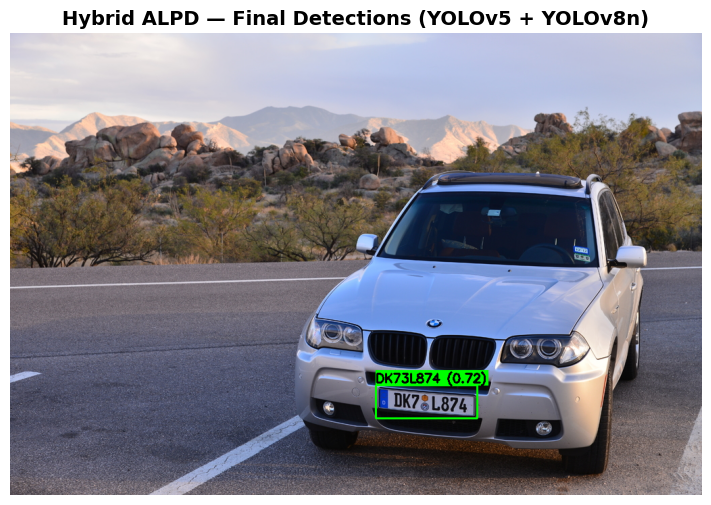

   📸 Saved: /content/alpd/results/8175301caa4b7a58_result.jpg


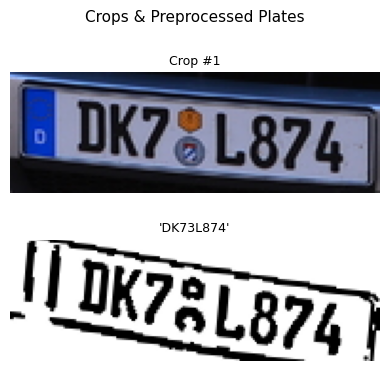


✅ Pipeline complete.
   Detected plates: ['DK73L874']

🏁 Final Pipeline Output:
   Plate #1: 'DK73L874' | conf=0.718


In [41]:
# ============================================================
# RUN THE PIPELINE — Single image demonstration
# ============================================================

test_images = list((YOLO_DATA_DIR / 'test' / 'images').glob('*'))
if not test_images:
    test_images = list((YOLO_DATA_DIR / 'val' / 'images').glob('*'))

if test_images:
    sample_image = random.choice(test_images)
    print(f"\n🖼  Testing on: {sample_image.name}")

    pipeline_output = run_full_pipeline(
        input_source   = sample_image,
        yolov5_weights = yolov5_weights,
        yolov8_weights = yolov8_weights,
        conf_threshold = 0.25,
        wbf_iou_thr    = 0.55,
        visualise      = True
    )

    print("\n🏁 Final Pipeline Output:")
    for i, res in enumerate(pipeline_output):
        print(f"   Plate #{i+1}: '{res['plate_text']}' | conf={res['confidence']:.3f}")
else:
    print("⚠️  No test images found — run dataset preparation first.")

In [19]:
# ============================================================
# BATCH INFERENCE — param rename yolov7 → yolov8. Logic UNCHANGED.
# ============================================================

def run_batch_inference(
    image_dir: Path,
    yolov5_weights: Path,
    yolov8_weights: Path,
    conf_threshold: float = 0.25,
    max_images: int = 20
) -> list:
    """Run full pipeline on all images in a directory."""
    image_files = sorted(image_dir.glob('*'))[:max_images]
    all_results = []

    for img_path in tqdm(image_files, desc='Batch inference'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        try:
            res = run_full_pipeline(
                img_path, yolov5_weights, yolov8_weights,
                conf_threshold=conf_threshold, visualise=False
            )
            plates = [r['plate_text'] for r in res if r['plate_text']]
        except Exception as e:
            print(f"⚠️  Error on {img_path.name}: {e}")
            plates = []
        all_results.append({'image': img_path.name, 'plates': plates})

    print(f"\n✅ Batch complete — {len(all_results)} images processed.")
    detected = [(r['image'], r['plates']) for r in all_results if r['plates']]
    print(f"   Images with plates: {len(detected)}")
    for img_name, plates in detected[:10]:
        print(f"   {img_name}: {plates}")
    return all_results


# ── ▶  Uncomment to run batch ────────────────────────────────
# batch_results = run_batch_inference(
#     YOLO_DATA_DIR / 'test' / 'images',
#     yolov5_weights, yolov8_weights,
#     max_images=50
# )

print("✅ Batch inference function defined.")

✅ Batch inference function defined.


---
## Section 10: Performance Metrics
### Accuracy · Precision · Recall · F1 · ROC Curve · Confusion Matrix

Detection metrics are computed per-image using IoU threshold = 0.5 to classify
each predicted box as TP (matched a GT box) or FP (no match), and to identify FN
(GT boxes not matched by any prediction).

In [20]:
# ============================================================
# SECTION 10A — IoU helpers + TP/FP/FN builder
# Used to turn raw detection outputs into sklearn-compatible
# binary labels for Precision / Recall / F1 / ROC / CM.
# ============================================================

def compute_iou(box_a: list, box_b: list) -> float:
    """
    Compute Intersection over Union between two boxes.

    Args:
        box_a, box_b : [x1, y1, x2, y2]  (any consistent scale)

    Returns:
        IoU score in [0, 1]
    """
    xa1 = max(box_a[0], box_b[0]);  ya1 = max(box_a[1], box_b[1])
    xa2 = min(box_a[2], box_b[2]);  ya2 = min(box_a[3], box_b[3])
    inter = max(0, xa2 - xa1) * max(0, ya2 - ya1)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def build_detection_labels(
    pred_boxes_list:  list,   # per-image list of predicted [x1,y1,x2,y2] (normalised)
    pred_scores_list: list,   # per-image confidence scores
    gt_boxes_list:    list,   # per-image ground-truth [x1,y1,x2,y2] (normalised)
    iou_threshold:    float = 0.5
) -> tuple:
    """
    Match predicted boxes to ground-truth boxes using IoU threshold.

    For each image:
      • A predicted box with IoU >= iou_threshold vs any unmatched GT box → TP.
      • A predicted box with no sufficient IoU match → FP.
      • A GT box matched by no prediction → FN (appended as missed detection).

    Returns two flat arrays suitable for sklearn metrics:
        y_true  : 1 = ground-truth positive (object exists), 0 = FP slot
        y_scores: confidence score for each entry (used for ROC)
    """
    y_true   = []
    y_scores = []

    for pred_boxes, pred_scores, gt_boxes in zip(
            pred_boxes_list, pred_scores_list, gt_boxes_list):

        matched_gt = set()

        # Sort predictions by confidence descending (greedy matching)
        order = sorted(range(len(pred_scores)),
                       key=lambda i: pred_scores[i], reverse=True)

        for i in order:
            pb    = pred_boxes[i]
            score = pred_scores[i]
            best_iou = 0.0
            best_j   = -1

            for j, gb in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_j   = j

            if best_iou >= iou_threshold and best_j >= 0:
                matched_gt.add(best_j)
                y_true.append(1)    # TP
                y_scores.append(score)
            else:
                y_true.append(0)    # FP
                y_scores.append(score)

        # FN — GT boxes that were never matched
        for j in range(len(gt_boxes)):
            if j not in matched_gt:
                y_true.append(1)    # true positive that was missed
                y_scores.append(0.0)  # score = 0 (model missed it)

    return np.array(y_true), np.array(y_scores)


print("✅ IoU helpers and label builder defined.")

✅ IoU helpers and label builder defined.


In [21]:
# ============================================================
# SECTION 10B — Load ground-truth boxes from test labels
# and run both models on the test set to collect predictions.
# ============================================================

def load_ground_truth_boxes(label_dir: Path, image_dir: Path) -> dict:
    """
    Load YOLO-format ground-truth label files.

    Returns:
        dict mapping image filename → list of [x1,y1,x2,y2] (normalised)
    """
    gt_map = {}
    for lbl_path in sorted(label_dir.glob('*.txt')):
        boxes = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                x1 = cx - bw / 2;  y1 = cy - bh / 2
                x2 = cx + bw / 2;  y2 = cy + bh / 2
                boxes.append([max(0,x1), max(0,y1), min(1,x2), min(1,y2)])
        # Match to image filename (any extension)
        for ext in ('.jpg', '.jpeg', '.png', '.bmp'):
            img_name = lbl_path.stem + ext
            if (image_dir / img_name).exists():
                gt_map[img_name] = boxes
                break
    print(f"✅ Loaded GT boxes for {len(gt_map)} images.")
    return gt_map


def collect_predictions_on_test_set(
    gt_map: dict,
    image_dir: Path,
    yolov5_weights: Path,
    yolov8_weights: Path,
    conf_threshold: float = 0.25,
    wbf_iou_thr: float    = 0.55,
    max_images: int       = 100
) -> tuple:
    """
    Run the full fusion pipeline on the test set and collect:
        pred_boxes_list  : predictions per image
        pred_scores_list : confidence scores per image
        gt_boxes_list    : ground-truth boxes per image
    """
    pred_boxes_list  = []
    pred_scores_list = []
    gt_boxes_list    = []

    image_files = sorted(gt_map.keys())[:max_images]

    for img_name in tqdm(image_files, desc='Collecting predictions'):
        img_path = image_dir / img_name
        image    = cv2.imread(str(img_path))
        if image is None:
            continue

        # Run both models
        v5_boxes, v5_scores, v5_labels = run_yolov5_inference(
            image, yolov5_weights, conf_threshold)
        v8_boxes, v8_scores, v8_labels = run_yolov8_inference(
            image, yolov8_weights, conf_threshold)

        # Fuse
        fused_boxes, fused_scores, _ = fuse_predictions(
            v5_boxes, v5_scores, v5_labels,
            v8_boxes, v8_scores, v8_labels,
            iou_thr=wbf_iou_thr
        )

        pred_boxes_list.append(fused_boxes)
        pred_scores_list.append(fused_scores)
        gt_boxes_list.append(gt_map[img_name])

    print(f"✅ Collected predictions for {len(pred_boxes_list)} images.")
    return pred_boxes_list, pred_scores_list, gt_boxes_list


print("✅ GT loader and prediction collector defined.")

✅ GT loader and prediction collector defined.


In [22]:
# ============================================================
# SECTION 10C — Compute full metrics + plots
# Accuracy · Precision · Recall · F1 · ROC Curve · Confusion Matrix
# ============================================================

def compute_and_plot_metrics(
    pred_boxes_list:  list,
    pred_scores_list: list,
    gt_boxes_list:    list,
    iou_threshold:    float = 0.5,
    conf_cutoff:      float = 0.5,
    save_dir:         Path  = RESULTS_DIR
) -> dict:
    """
    Compute detection performance metrics from raw prediction lists.

    Workflow:
      1. build_detection_labels() → y_true (binary), y_scores (floats)
      2. Threshold scores at conf_cutoff → y_pred binary labels
      3. Compute Accuracy, Precision, Recall, F1 using sklearn
      4. Compute ROC curve + AUC
      5. Plot ROC curve + Confusion Matrix

    Args:
        pred_boxes_list  : List (per image) of predicted box lists.
        pred_scores_list : List (per image) of confidence score lists.
        gt_boxes_list    : List (per image) of GT box lists.
        iou_threshold    : IoU cutoff for TP/FP assignment.
        conf_cutoff      : Confidence threshold for binary y_pred.
        save_dir         : Where to save plot images.

    Returns:
        dict of all computed metric values.
    """
    save_dir.mkdir(parents=True, exist_ok=True)

    # ── Step 1: Build binary labels ──────────────────────────
    y_true, y_scores = build_detection_labels(
        pred_boxes_list, pred_scores_list, gt_boxes_list,
        iou_threshold=iou_threshold
    )

    if len(y_true) == 0:
        print("⚠️  No predictions or GT boxes found — cannot compute metrics.")
        return {}

    # ── Step 2: Binary predictions at conf_cutoff ────────────
    y_pred = (y_scores >= conf_cutoff).astype(int)

    # ── Step 3: sklearn classification metrics ───────────────
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    metrics = {
        'accuracy' : accuracy,
        'precision': precision,
        'recall'   : recall,
        'f1_score' : f1,
        'iou_threshold' : iou_threshold,
        'conf_cutoff'   : conf_cutoff,
        'n_samples'     : len(y_true),
        'n_positives'   : int(y_true.sum()),
        'n_negatives'   : int((1 - y_true).sum())
    }

    print("\n" + "="*50)
    print("  📊 DETECTION PERFORMANCE METRICS")
    print(f"  IoU threshold : {iou_threshold}  |  Conf cutoff : {conf_cutoff}")
    print("="*50)
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Samples   : {len(y_true)}  (TP+FN={y_true.sum()}, FP={int((1-y_true).sum())})")
    print("="*50)

    # ── Step 4: ROC curve ────────────────────────────────────
    if len(np.unique(y_true)) > 1:   # need both classes for ROC
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc              = auc(fpr, tpr)
        metrics['auc']       = roc_auc

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ── ROC Curve ──
        ax = axes[0]
        ax.plot(fpr, tpr, color='royalblue', lw=2,
                label=f'ROC Curve (AUC = {roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
        ax.fill_between(fpr, tpr, alpha=0.1, color='royalblue')
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate',  fontsize=12)
        ax.set_title('ROC Curve — Hybrid YOLOv5 + YOLOv8n\n'
                     f'(IoU thr={iou_threshold}, conf cutoff={conf_cutoff})',
                     fontsize=12)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.02])

        # ── Confusion Matrix ──
        ax2 = axes[1]
        cm  = confusion_matrix(y_true, y_pred)
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Pred: No Plate', 'Pred: Plate'],
            yticklabels=['GT: No Plate',   'GT: Plate'],
            linewidths=0.5, linecolor='gray'
        )
        ax2.set_title('Confusion Matrix\n'
                      f'(Accuracy={accuracy:.3f}, F1={f1:.3f})', fontsize=12)
        ax2.set_ylabel('Ground Truth', fontsize=11)
        ax2.set_xlabel('Prediction',   fontsize=11)

        # Annotate TP / FP / FN / TN
        labels_cm = [['TN', 'FP'], ['FN', 'TP']]
        for i in range(2):
            for j in range(2):
                ax2.text(j + 0.5, i + 0.75, labels_cm[i][j],
                         ha='center', va='center',
                         fontsize=10, color='grey')

        plt.tight_layout()
        save_path = save_dir / 'metrics_roc_cm.png'
        plt.savefig(str(save_path), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n   📈 ROC AUC : {roc_auc:.4f}")
        print(f"   📸 Plot saved: {save_path}")

    else:
        print("⚠️  Only one class in y_true — skipping ROC curve.")
        print("    (This happens when all predictions are TP or all are FP.)")

    return metrics


print("✅ compute_and_plot_metrics() defined.")

✅ compute_and_plot_metrics() defined.


✅ Loaded GT boxes for 538 images.


✅ Collected predictions for 100 images.

  📊 DETECTION PERFORMANCE METRICS
  IoU threshold : 0.5  |  Conf cutoff : 0.5
  Accuracy  : 0.7590
  Precision : 0.9286
  Recall    : 0.7647
  F1 Score  : 0.8387
  Samples   : 166  (TP+FN=136, FP=30)


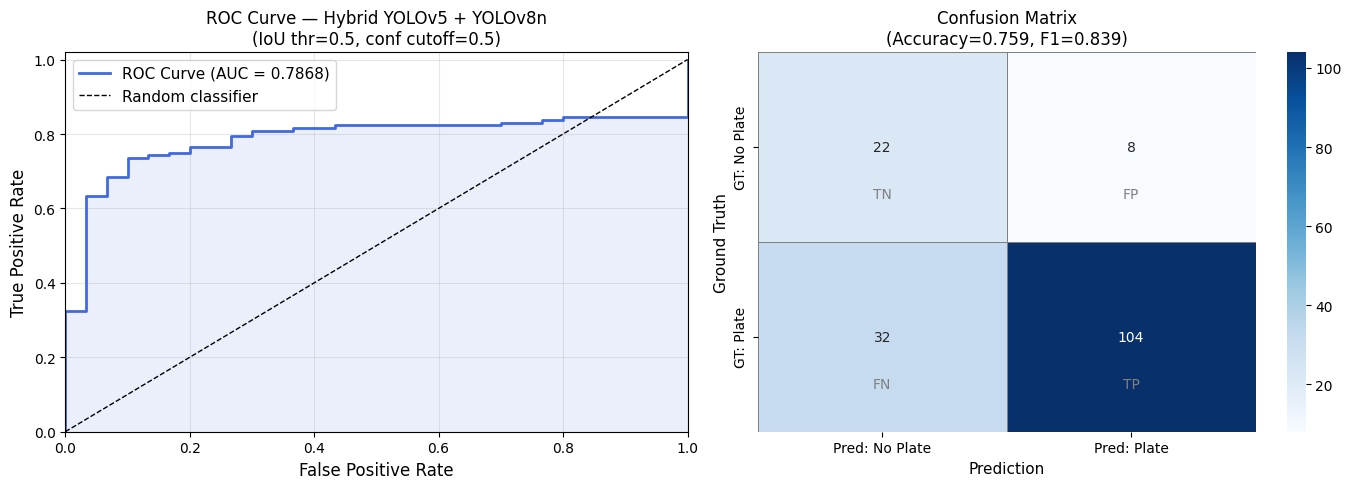


   📈 ROC AUC : 0.7868
   📸 Plot saved: /content/alpd/results/metrics_roc_cm.png

🏁 Final Metrics Summary:
   accuracy            : 0.7590
   precision           : 0.9286
   recall              : 0.7647
   f1_score            : 0.8387
   iou_threshold       : 0.5000
   conf_cutoff         : 0.5000
   n_samples           : 166
   n_positives         : 136
   n_negatives         : 30
   auc                 : 0.7868


In [23]:
# ============================================================
# SECTION 10D — Run full metrics evaluation on test set
# ============================================================

TEST_IMG_DIR = YOLO_DATA_DIR / 'test' / 'images'
TEST_LBL_DIR = YOLO_DATA_DIR / 'test' / 'labels'

# Step 1: Load ground-truth boxes
gt_map = load_ground_truth_boxes(TEST_LBL_DIR, TEST_IMG_DIR)

# Step 2: Collect fused predictions on test set
# Increase max_images for a more reliable estimate (costs more time)
pred_boxes_list, pred_scores_list, gt_boxes_list = collect_predictions_on_test_set(
    gt_map          = gt_map,
    image_dir       = TEST_IMG_DIR,
    yolov5_weights  = yolov5_weights,
    yolov8_weights  = yolov8_weights,
    conf_threshold  = 0.25,
    wbf_iou_thr     = 0.55,
    max_images      = 100        # ← increase to use full test set
)

# Step 3: Compute & plot metrics
final_metrics = compute_and_plot_metrics(
    pred_boxes_list  = pred_boxes_list,
    pred_scores_list = pred_scores_list,
    gt_boxes_list    = gt_boxes_list,
    iou_threshold    = 0.5,
    conf_cutoff      = 0.5,
    save_dir         = RESULTS_DIR
)

print("\n🏁 Final Metrics Summary:")
for k, v in final_metrics.items():
    if isinstance(v, float):
        print(f"   {k:<20}: {v:.4f}")
    else:
        print(f"   {k:<20}: {v}")

In [66]:
def compute_iou_norm(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x2g - x1g) * (y2g - y1g)

    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

In [67]:
def load_gt_normalized(test_images: list) -> dict:
    gt_annotations = {}

    for img_path in test_images:
        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

        boxes = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    cls, xc, yc, w, h = map(float, line.split())

                    x1 = xc - w/2
                    y1 = yc - h/2
                    x2 = xc + w/2
                    y2 = yc + h/2

                    boxes.append([x1, y1, x2, y2])

        gt_annotations[img_path] = boxes

    return gt_annotations

In [70]:
from typing import Dict
import numpy as np
import cv2

def evaluate_hybrid(
    test_images: list,
    weights_v5: Path,
    weights_v8: Path
) -> Dict:

    print("\n🔄 Running Hybrid Evaluation...")

    gt_annotations = load_gt_normalized(test_images)

    precisions = []
    recalls    = []

    for idx, img_path in enumerate(test_images):
        print(f"   Processing {idx+1}/{len(test_images)}", end="\r")

        img = cv2.imread(img_path)
        if img is None:
            continue

        gt_boxes = gt_annotations.get(img_path, [])

        # --- YOLOv5 ---
        v5_boxes, v5_scores, _ = run_yolov5_inference(
            img, weights_v5
        )

        # --- YOLOv8 ---
        v8_boxes, v8_scores, _ = run_yolov8_inference(
            img, weights_v8
        )

        # Create dummy labels (since single class: license plate)
        v5_labels = [0] * len(v5_boxes)
        v8_labels = [0] * len(v8_boxes)

        # Correct fusion call
        hybrid_boxes, hybrid_scores, hybrid_labels = fuse_predictions(
            v5_boxes, v5_scores, v5_labels,
            v8_boxes, v8_scores, v8_labels
        )

        # --- Evaluate ---
        tp, fp = 0, 0
        matched = set()

        for p in hybrid_boxes:
            found = False
            for i, g in enumerate(gt_boxes):
                if i in matched:
                    continue
                if compute_iou_norm(p, g) >= 0.5:
                    tp += 1
                    matched.add(i)
                    found = True
                    break
            if not found:
                fp += 1

        fn = len(gt_boxes) - len(matched)

        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)

        precisions.append(precision)
        recalls.append(recall)

    results = {
        'precision': float(np.mean(precisions)) if precisions else 0.0,
        'recall'   : float(np.mean(recalls)) if recalls else 0.0
    }

    print("\n\n📊 Hybrid Evaluation:")
    for k, v in results.items():
        print(f"   {k:<15}: {v:.4f}")

    return results

In [71]:
# Build test set
val_dir = "/content/alpd/dataset/images/val"

test_images = [
    os.path.join(val_dir, f)
    for f in os.listdir(val_dir)
    if f.endswith(".jpg")
][:50]

print("Total test images:", len(test_images))

# Run
hybrid_metrics = evaluate_hybrid(
    test_images,
    yolov5_weights,
    yolov8_weights
)

Total test images: 50

🔄 Running Hybrid Evaluation...
   Processing 50/50

📊 Hybrid Evaluation:
   precision      : 0.8300
   recall         : 0.9167
